In [73]:
import seaborn as sns
import pandas as pd
import json
from pathlib import Path
from matplotlib.patches import Ellipse
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import ListedColormap

In [74]:
result_path = Path("../results/downstream_task")
bias_type = "less_positive_class"
less_bias_strength = "0.1"
method = "fw-mrs-temperature-comparison"
data_set_name = "folktables_income"

In [75]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_individual_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_individual_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

In [76]:
dropped_samples

,0.5,0.25,0.1,0.05,0.025,0.01,0.005,0.0025,0.001,0.0
0,200,180,185,185,180,150,140,120,110,210
1,160,175,150,150,125,115,110,100,60,140
2,160,155,165,145,150,115,110,85,95,180
3,175,165,165,165,135,105,100,80,65,175
4,100,90,115,105,70,75,65,65,65,115
5,220,180,170,185,190,175,135,155,155,210
6,150,185,170,180,160,145,110,135,130,170
7,175,175,160,150,140,95,100,125,110,190
8,185,170,160,145,145,110,95,90,95,180
9,230,240,225,220,215,195,195,180,180,235


In [77]:
aurocs

,0.5,0.25,0.1,0.05,0.025,0.01,0.005,0.0025,0.001,0.0
0,0.833599,0.833556,0.831408,0.823270,0.810630,0.783523,0.770150,0.748993,0.727184,0.837557
1,0.840739,0.839229,0.836545,0.834247,0.825504,0.801381,0.784943,0.747247,0.712387,0.839480
2,0.825141,0.824690,0.824983,0.816620,0.799444,0.771423,0.767844,0.664277,0.695302,0.826371
3,0.836932,0.838036,0.832934,0.826510,0.815384,0.790499,0.777175,0.748050,0.713374,0.842781
4,0.836580,0.836159,0.825138,0.827216,0.818286,0.788096,0.766872,0.731648,0.707838,0.836715
5,0.851298,0.851821,0.858074,0.856028,0.837492,0.812799,0.800028,0.761768,0.738315,0.855894
6,0.844567,0.846336,0.842941,0.834785,0.825054,0.795158,0.785823,0.751371,0.716304,0.842877
7,0.833175,0.830815,0.829155,0.802473,0.810666,0.775454,0.788353,0.758972,0.714221,0.836533
8,0.843540,0.843095,0.838209,0.834650,0.814815,0.783194,0.767665,0.754055,0.694096,0.844670
9,0.848581,0.853436,0.849565,0.834280,0.828726,0.790691,0.770200,0.723842,0.704017,0.850995


In [78]:
temperatures = dropped_samples.drop(columns=["0.0"]).keys().astype(float)
temperatures  = temperatures.insert(0, 0.0)

temperature_labels = temperatures.astype(str).array
temperature_labels[0] = "MRS"
temperature_labels

<NumpyExtensionArray>
[   'MRS',    '0.5',   '0.25',    '0.1',   '0.05',  '0.025',   '0.01',
  '0.005', '0.0025',  '0.001']
Length: 10, dtype: object

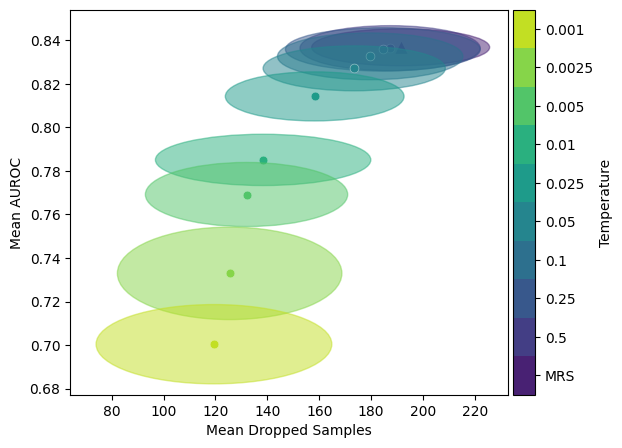

In [79]:
palette = sns.color_palette("viridis", n_colors=len(temperatures))
cmap = ListedColormap(palette)
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0
min_x = np.inf
min_y = np.inf

for i, (key, dropped_value) in enumerate(dropped_samples[temperatures.astype(str)].items()):
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(i)
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size,)
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    min_x = min(min_x, dropped_value.mean() - dropped_value.std())
    min_y = min(min_y, auroc_value.mean() - auroc_value.std())
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                orientation='vertical')
cbar.set_label('Temperature')
cbar.set_ticks(np.linspace(0.05,0.95,10))
cbar.set_ticklabels(temperature_labels)
ax.set_xlim(min_x - 10)
ax.set_ylim(min_y - 0.005)

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")
plt.savefig("diagrams/temperature_comparison_fixed.pdf", bbox_inches="tight")

In [80]:
dropped_samples_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "dropped_samples_val_dict.json"
with open(dropped_samples_file_name) as file:
        dropped_samples = json.load(file)
        dropped_samples = pd.DataFrame(dropped_samples)
auroc_file_name = result_path / data_set_name / bias_type / less_bias_strength / method / "validation" / "auroc_val_dict.json"
with open(auroc_file_name) as file:
        aurocs = json.load(file)
        aurocs = pd.DataFrame(aurocs)

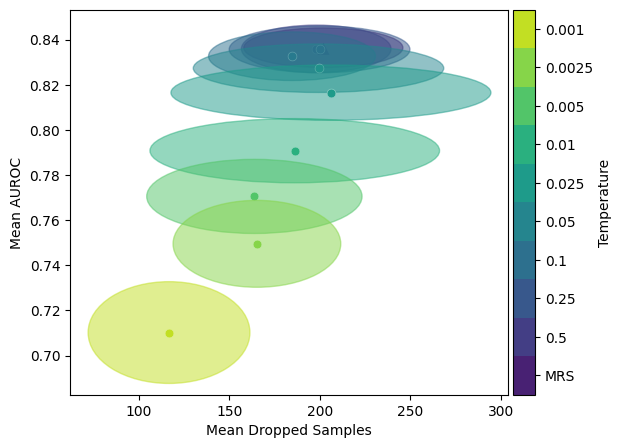

In [81]:
palette = sns.color_palette("viridis", n_colors=len(temperatures))
cmap = ListedColormap(palette)
fig = plt.figure(figsize=(6,5))
mrs_value = 0.0
min_x = np.inf
min_y = np.inf

for i, (key, dropped_value) in enumerate(dropped_samples[temperatures.astype(str)].items()):
    auroc_value = aurocs[key]
    if float(key) == mrs_value:
        marker= "^"
        size= 100
    else: 
        marker = "o"
        size= 40
        
    color = cmap(i)
    ax = sns.scatterplot(x=[dropped_value.mean()], y=[auroc_value.mean()], label=key, alpha=1, color=color, marker=marker,
                         s=size, )
    ellipse = Ellipse((dropped_value.mean(), auroc_value.mean()),
                       width=2*dropped_value.std(), height=2*auroc_value.std(), alpha=0.5,
                       color=color)
    min_x = min(min_x, dropped_value.mean() - dropped_value.std())
    min_y = min(min_y, auroc_value.mean() - auroc_value.std())
    ax.add_patch(ellipse)

plt.gca().legend_.remove()

divider = make_axes_locatable(plt.gca())
ax_cb = divider.new_horizontal(size="5%", pad=0.05)
fig.add_axes(ax_cb)
cbar = matplotlib.colorbar.ColorbarBase(ax_cb, cmap=cmap,
                                orientation='vertical')
cbar.set_label('Temperature')
cbar.set_ticks(np.linspace(0.05,0.95,10))

cbar.set_ticklabels(temperature_labels)
ax.set_xlim(min_x - 10)
ax.set_ylim(min_y - 0.005)

_= ax.set(xlabel="Mean Dropped Samples", ylabel="Mean AUROC")
plt.savefig("diagrams/temperature_comparison_optimized.pdf", bbox_inches="tight")